Charger les bibliothèques et réglages communs


In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

Charger des bibliothèques supplémentaires

In [2]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

#  Décomposition des séries temporelles

Les données de séries temporelles peuvent présenter une variété de motifs, et il est souvent utile de diviser une série chronologique en plusieurs composantes, chacune représentant une catégorie de motifs sous-jacente.

Nous avons discuté de trois types de schémas de séries temporelles : tendance, saisonnalité et cycles. Lorsque nous décomposons une série temporelle en composantes, nous combinons généralement la tendance et le cycle en une seule composante **du cycle de tendance** (souvent appelée simplement la **tendance** pour simplifier). Ainsi, on peut considérer une série temporelle comme comprenant trois composantes : une composante du cycle de tendance, une composante saisonnière et une composante du reste (contenant tout ce qui appartient à la série chronologique). Pour certaines séries temporelles (par exemple, celles observées au moins quotidiennement), il peut y avoir plus d’une composante saisonnière, correspondant aux différentes périodes saisonnières.

Dans ce chapitre, nous considérons les méthodes les plus courantes pour extraire ces composants d’une série temporelle. Souvent, cela est fait pour améliorer la compréhension des séries chronologiques, mais cela peut aussi servir à améliorer la précision des prévisions.

Lors de la décomposition d’une série temporelle, il est parfois utile de d’abord transformer ou d’ajuster la série afin de simplifier la décomposition (et l’analyse ultérieure) au maximum. Nous commencerons donc par discuter des transformations et des ajustements.

## Transformations et ajustements

Ajuster les données historiques peut souvent conduire à une série temporelle plus simple. Ici, nous traitons de quatre types d’ajustements : les ajustements de calendrier, les ajustements de population, les ajustements d’inflation et les transformations mathématiques. Le but de ces ajustements et transformations est de simplifier les motifs dans les données historiques en supprimant les sources connues de variation, ou en rendant le motif plus cohérent sur l’ensemble de l’ensemble des données. Les schémas plus simples sont généralement plus faciles à modéliser et conduisent à des prévisions plus précises.

### Ajustements du calendrier

Une partie de la variation observée dans les données saisonnières peut être due à de simples effets de calendrier. Dans de tels cas, il est généralement beaucoup plus facile de supprimer la variation avant d’effectuer une analyse supplémentaire.

Par exemple, si vous étudiez les ventes mensuelles totales dans un magasin de détail, il y aura des variations entre les mois simplement en raison du nombre différent de jours de transaction dans chaque mois, en plus de la variation saisonnière sur l’année. Il est facile de supprimer cette variation en calculant les ventes moyennes par jour de bourse de chaque mois, plutôt que les ventes totales du mois. Ensuite, nous supprimons effectivement la variation du calendrier.

### Ajustements démographiques

Toute donnée affectée par les changements de population peut être ajustée pour donner des données par habitant. C’est-à-dire, considérez les données par personne (ou par mille personnes, ou par million) plutôt que le total. Par exemple, si vous étudiez le nombre de lits d’hôpital dans une région donnée au fil du temps, les résultats sont beaucoup plus faciles à interpréter si l’on élimine les effets des changements de population en tenant compte du nombre de lits pour mille habitants. On peut alors voir s’il y a eu une réelle augmentation du nombre de lits, ou si cette augmentation est entièrement due à l’augmentation de la population. Il est possible que le nombre total de lits augmente, mais que le nombre de lits pour mille personnes diminue. Cela se produit lorsque la population augmente plus rapidement que le nombre de lits d’hôpital. Pour la plupart des données affectées par les changements démographiques, il est préférable d’utiliser les données par habitant plutôt que les totaux.

Cela se voit dans le jeu de données, où une transformation courante du PIB est le PIB par habitant

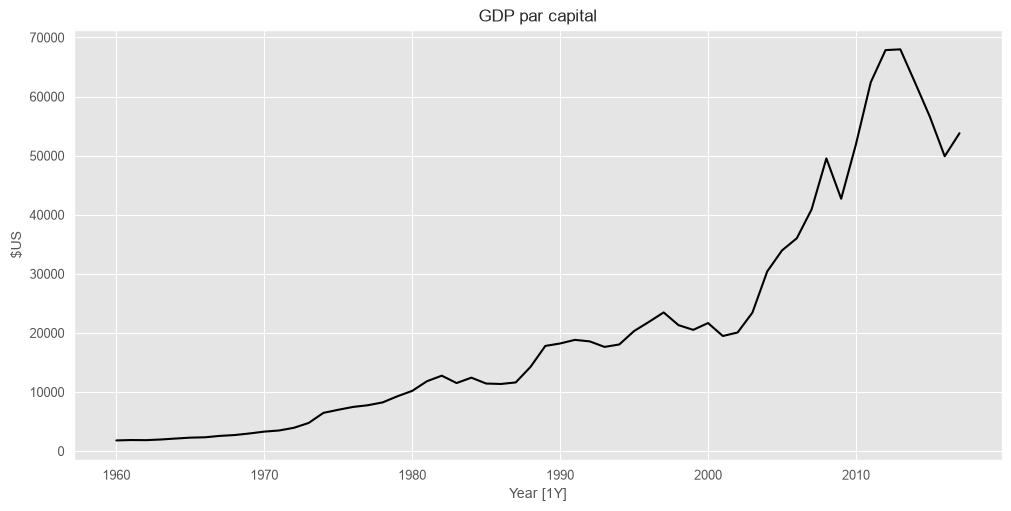

In [3]:
global_economy = pd.read_csv("data/global_economy.csv")

df = (
    global_economy
    .loc[lambda x: x["unique_id"] == "Australia"]
    .assign(y=lambda x: x["GDP"] / x["Population"])
)

plt.figure(figsize=(10, 5))
plt.plot(df["ds"], df["y"])

plt.xlabel("Year [1Y]")
plt.ylabel("$US")
plt.title("GDP par capital")

plt.show()

Figure: PIB par habitant australien

### Ajustements d’inflation

Les données influencées par la valeur de la monnaie sont mieux ajustées avant modélisation. Par exemple, le coût moyen d’une maison neuve aura augmenté au cours des dernières décennies en raison de l’inflation. Une maison à 200 000 $ cette année n’est pas la même chose qu’une maison à 200 000 $ il y a vingt ans. Pour cette raison, les séries temporelles financières sont généralement ajustées de sorte que toutes les valeurs soient exprimées en dollars d’une année donnée. Par exemple, les données sur les prix des logements peuvent être exprimées en dollars de l’an 2000.

Pour effectuer ces ajustements, un indice des prix est utilisé. Si $z_t$ désigne l’indice des prix et $y_t$ indique le prix d’origine de la maison en année $t$, alors :

$$
x_t = \frac{y_t}{z_t} \times z_{2000}
$$

indique le prix ajusté de la maison en valeur de dollars de l’année 2000. Les indices des prix sont souvent élaborés par des agences gouvernementales. Pour les biens de consommation, un indice des prix commun est l’indice des prix à la consommation (ou IPC).

Cela nous permet de comparer la croissance ou le déclin des industries par rapport à une valeur de prix commune. Par exemple, en regardant le chiffre d’affaires annuel agrégé « journaux et livres » dans la vente au détail à partir de `aus_retail` et en ajustant les données pour l’inflation à partir de l’IPC de `global_economy`, on comprend les évolutions au fil du temps.

In [ ]:
aus_retail = pd.read_csv("data/aus_retail.csv", parse_dates=["Month"])
print_retail = (
    aus_retail
    .loc[lambda x: x["Industry"] == "Newspaper and book retailing"]
    .assign(ds=lambda x: x["Month"].dt.year)
    .groupby("ds", as_index=False)
    ["Turnover"].sum()
)
aus_economy = global_economy.loc[lambda x: x["unique_id"] == "Australia"]
df = (
    aus_economy
    .merge(print_retail, on="ds", how="left")
    .assign(adjusted_turnover=lambda x: x["Turnover"] / x["CPI"] * 100)
    .dropna()
)
fig, axes = plt.subplots(2, 1, sharex=True)
sns.lineplot(data=df, x='ds', y='Turnover', ax=axes[0],
    color='black', label="Turnover")
sns.lineplot(data=df, x='ds', y='adjusted_turnover', ax=axes[1],
    color='black', label="Adjusted_turnover")
axes[0].set(ylabel="")
axes[1].set(ylabel="", xlabel='Year')
fig.suptitle("Chiffre d’affaires : industrie australienne de la presse imprimée")
fig.supylabel("$AU")
plt.show()

Figure : Chiffre d’affaires de l’industrie australienne des médias imprimés en dollars australiens. Le chiffre d’affaires « ajusté » a été ajusté à l’inflation en utilisant l’IPC.

### Ajustements d’inflation

En ajustant pour l’inflation à l’aide de l’IPC, on peut constater que l’industrie australienne de la presse et de la librairie est en déclin bien plus longtemps que ce que suggèrent les données initiales. Le chiffre d’affaires ajusté est en dollars australiens de 2010, l’IPC étant de 100 en 2010 dans cet ensemble de données.

### Transformations mathématiques

Si les données montrent une variation qui augmente ou diminue avec le niveau de la série, alors une transformation peut être utile. Par exemple, une transformation logarithmique est souvent utile. Si l’on note les observations originales comme `y1,…,yT` et les observations transformées comme `w1,…,wT`, alors :

$$
w_t = \log(y_t)
$$

Les logarithmes sont utiles car ils sont interprétables : les variations d’une valeur logarithmique sont des variations relatives (ou en pourcentage) sur l’échelle d’origine. Ainsi, si on utilise la base logarithmique 10, alors une augmentation de 1 sur l’échelle logarithmique correspond à une multiplication de 10 sur l’échelle originale. Si une valeur de la série originale est nulle ou négative, alors les logarithmes ne sont pas possibles.

Parfois, d’autres transformations sont également utilisées (bien qu’elles ne soient pas aussi interprétables). Par exemple, des racines carrées et des racines cubiques peuvent être utilisées. On les appelle **des transformations de puissance** car elles peuvent s’écrire sous la forme suivante :

$$
w_t = y_t^p
$$

Une famille utile de transformations, qui inclut à la fois les logarithmes et les transformations de puissance, est la famille des **transformations de Box-Cox**, qui dépendent du paramètre `λ` et sont définies comme suit :

$$
w_t =
\begin{cases}
\log(y_t), & \text{si } \lambda = 0,\\[6pt]
\displaystyle\frac{\operatorname{Signe}(y_t)|y_t|^\lambda - 1}{\lambda}, & \text{sinon}.
\end{cases}
\tag{3.1}
$$

Il s’agit en réalité d’une transformation de Box-Cox modifiée, discutée dans Bickel & Doksum (1981), qui permet des valeurs négatives de `yt` pourvu `λ>0`.

Le logarithme dans une transformation de Box-Cox est toujours un logarithme naturel (c’est-à-dire à la base `e`). Donc si `λ=0`, des logarithmes naturels sont utilisés, mais si `λ≠0`, une transformation de puissance est utilisée, suivie d’un simple ajustement de la puissance.

Si `λ=1`, alors `wt=yt−1`, donc les données transformées sont déplacées vers le bas mais il n’y a pas de changement dans la forme de la série temporelle. Pour toutes les autres valeurs de `λ`, la série temporelle changera de forme.

Un bon rapport qualité-prix de `λ` est un modèle qui rend la taille de la variation saisonnière à peu près identique sur toute la série, car cela simplifie le modèle de prévision.

In [21]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


# Chargement des données
aus_production = pd.read_csv(
    "data/aus_production.csv",
    parse_dates=["ds"]
)

# Sélection de la production de gaz
aus_gas = (
    aus_production[["ds", "Gas"]]
    .rename(columns={"Gas": "y"})
    .dropna()
    .reset_index(drop=True)
)


# Transformation de Box-Cox
def boxcox_transform(y, lam):
    if lam == 0:
        return np.log(y)
    else:
        return (y**lam - 1) / lam


# Fonction qui met à jour le graphique
def afficher_transformation(lam):

    y = aus_gas["y"].to_numpy()

    y_transformed = boxcox_transform(y, lam)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        aus_gas["ds"],
        y_transformed,
        linewidth=1
    )

    ax.set_title(
        "Production trimestrielle de gaz en Australie",
        fontsize=18
    )

    ax.set_xlabel("Année")
    ax.set_ylabel("Production de gaz transformée")

    ax.grid(True)

    plt.show()
    plt.close(fig)  # évite l'accumulation de figures à chaque appel


# Curseur λ
lambda_slider = widgets.FloatSlider(
    value=1.4,
    min=-1,
    max=2,
    step=0.1,
    description="Paramètre de transformation : λ",
    continuous_update=True,
    readout_format=".1f",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)


# Création de la sortie
output = widgets.interactive_output(
    afficher_transformation,
    {"lam": lambda_slider}
)


# Affichage du curseur ET du graphique
display(lambda_slider)
display(output)

FloatSlider(value=1.4, description='Paramètre de transformation : λ', layout=Layout(width='500px'), max=2.0, m…

Output()

Figure : Transformations Box-Cox appliquées à la production trimestrielle australienne de gaz

Vous pouvez appliquer la transformation de Box-Cox directement aux données en utilisant la fonction `boxcox()` de `CoreForecast`. Pour déterminer automatiquement un `λ` pour la transformation de Box-Cox, utiliser la fonction `boxcox_lambda()` de `CoreForecast`. Cette fonction nécessite le `season_length` de la série et utilise la méthode de Guerrero (1993) pour choisir une valeur pour `λ`. Dans cet exemple, il choisit `λ=0.11`.

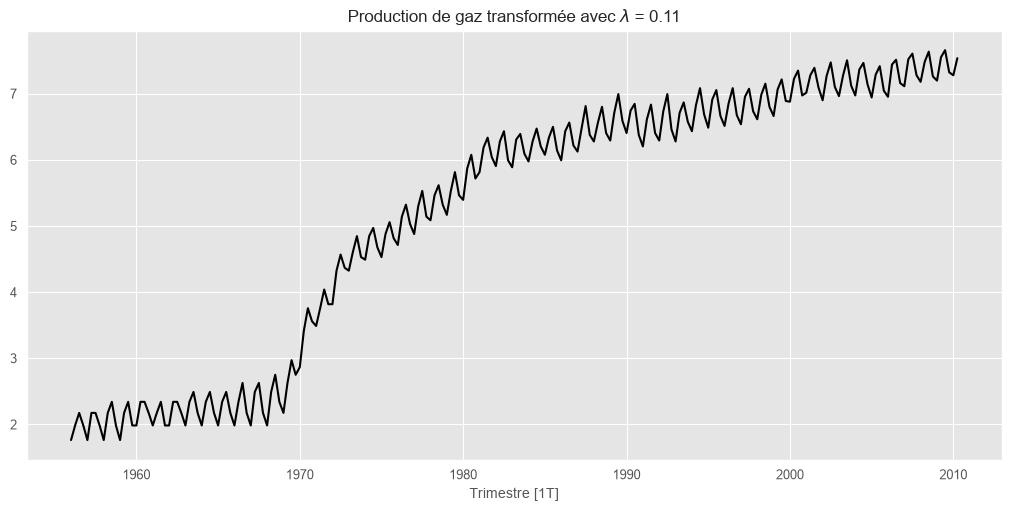

In [6]:

aus_production = pd.read_csv(
    "data/aus_production.csv",
    parse_dates=["ds"]
)

aus_gas = (
    aus_production[["ds", "Gas"]]
    .rename(columns={"Gas": "y"})
    .assign(unique_id="Gas")
)

y = aus_gas["y"].to_numpy()

optim_lambda = boxcox_lambda(
    y,
    method="guerrero",
    season_length=4
)

df = aus_gas.assign(
    y_transformed=boxcox(y, optim_lambda)
)

title = rf"Production de gaz transformée avec $\lambda$ = {optim_lambda:.2f}"

plt.figure(figsize=(10, 5))

plt.plot(
    df["ds"],
    df["y_transformed"]
)

plt.xlabel("Trimestre [1T]")
plt.ylabel("")
plt.title(title)
plt.grid(True)
plt.show()



Figure: Production de gaz australienne transformée avec `λ` choisie en utilisant la fonction de `boxcox_lambda()` de `CoreForecast`.

##  Composantes de la série chronologique

Si l’on suppose une décomposition additive, alors on peut écrire

$$
y_t = S_t + T_t + R_t,
$$

où `y_t` est la donnée, `S_t` est la composante saisonnière, `T_t` est la composante du cycle de tendance, et `R_t` est la composante restante, tout à la période `t`. Sinon, une décomposition multiplicative s’écrit comme

$$
y_t = S_t \times T_t \times R_t.
$$

La décomposition additive est la plus appropriée si l’ampleur des fluctuations saisonnières, ou la variation autour du cycle de tendance, ne varie pas avec le niveau de la série chronologique. Lorsque la variation du schéma saisonnier, ou la variation autour du cycle de tendance, semble proportionnelle au niveau de la série temporelle, alors une décomposition multiplicative est plus appropriée. Les décompositions multiplicatives sont courantes avec les séries temporelles économiques.

Une alternative à l’utilisation d’une décomposition multiplicative consiste d’abord à transformer les données jusqu’à ce que la variation de la série semble stable dans le temps, puis à utiliser une décomposition additive. Lorsqu’une transformation logarithmique a été utilisée, cela équivaut à utiliser une décomposition multiplicative sur les données originales car

$$
y_t = S_t \times T_t \times R_t
$$

est équivalent à

$$
\log(y_t) = \log(S_t) + \log(T_t) + \log(R_t).
$$

### Exemple : Emploi dans le secteur de la vente au détail américaine

Nous allons examiner plusieurs méthodes pour obtenir les composants `S_t`, `T_t` et `R_t` plus tard dans ce chapitre, mais il est d’abord utile de voir un exemple. Nous allons décomposer le nombre total mensuel de milliers de personnes employées dans le secteur de la distribution à travers les États-Unis depuis 1990.

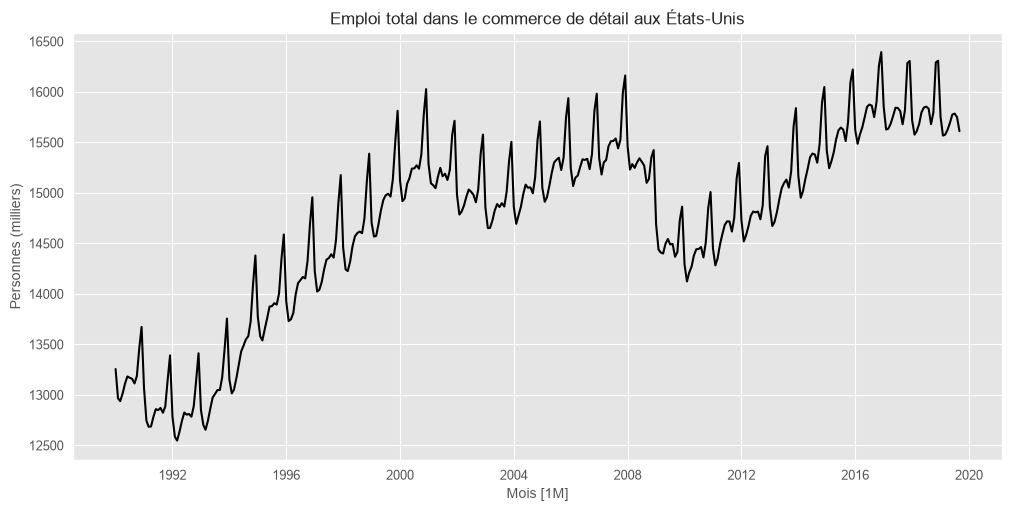

In [7]:
us_employment = pd.read_csv(
    "data/us_employment.csv",
    parse_dates=["ds"]
)

us_retail_employment = us_employment.loc[
    lambda x: (
        (x["unique_id"] == "Retail Trade")
        & (x["ds"] >= "1990")
    )
]

plt.figure(figsize=(10, 5))

plt.plot(
    us_retail_employment["ds"],
    us_retail_employment["y"]
)

plt.xlabel("Mois [1M]")
plt.ylabel("Personnes (milliers)")
plt.title("Emploi total dans le commerce de détail aux États-Unis")
plt.grid(True)

plt.show()



Figure: Nombre total de personnes employées dans le commerce de détail américain.

In [8]:
# Décomposition STL de la série temporelle
stl = STL(
    us_retail_employment["y"],
    period=12
)

# Ajustement du modèle STL
res = stl.fit()

# Création du DataFrame contenant les composantes
dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res.trend,
    "seasonal": res.seasonal,
    "remainder": res.resid,
}).reset_index(drop=True)

# Les quatre composantes obtenues sont :

# * `data` : série originale
# * `trend` : tendance
# * `seasonal` : composante saisonnière
# * `remainder` : résidus ou composante irrégulière

# Ici, `period=12` indique une **saisonnalité de 12 mois**, ce qui est adapté à une série mensuelle.
dcmp.head()

,ds,data,trend,seasonal,remainder
0,1990-01-01,13255.8,13296.249,-3.700,-36.749
1,1990-02-01,12966.3,13276.085,-288.398,-21.387
2,1990-03-01,12938.2,13255.663,-306.658,-10.805
3,1990-04-01,13012.3,13234.986,-235.775,13.089
4,1990-05-01,13108.3,13214.071,-115.399,9.628


La sortie ci-dessus montre les composantes d’une décomposition STL. Les données originales sont affichées (comme `data`), suivies des composantes estimées.
La colonne (contenant le cycle de tendance `T_t`) suit le déroulement global de la série, en ignorant toute saisonnalité et fluctuations aléatoires. Nous pouvons tracer toutes les composantes de la décomposition.

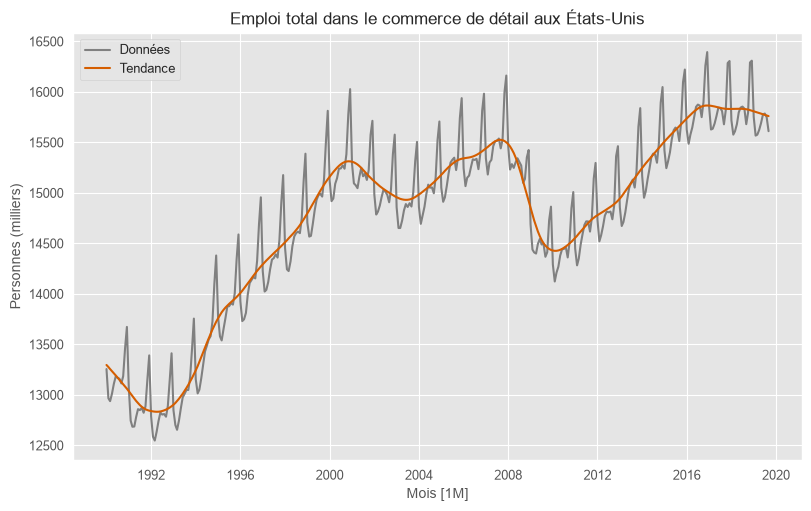

In [9]:

fig, ax = plt.subplots()

sns.lineplot(
    data=dcmp,
    x="ds",
    y="data",
    color="gray",
    label="Données"
)

sns.lineplot(
    data=dcmp,
    x="ds",
    y="trend",
    color="#D55E00",
    label="Tendance"
)

ax.set(
    title="Emploi total dans le commerce de détail aux États-Unis",
    xlabel="Mois [1M]",
    ylabel="Personnes (milliers)"
)

plt.show()




Figure: Nombre total de personnes employées dans le commerce de détail américain : la composante du cycle des tendances (orange) et les données brutes (gris)

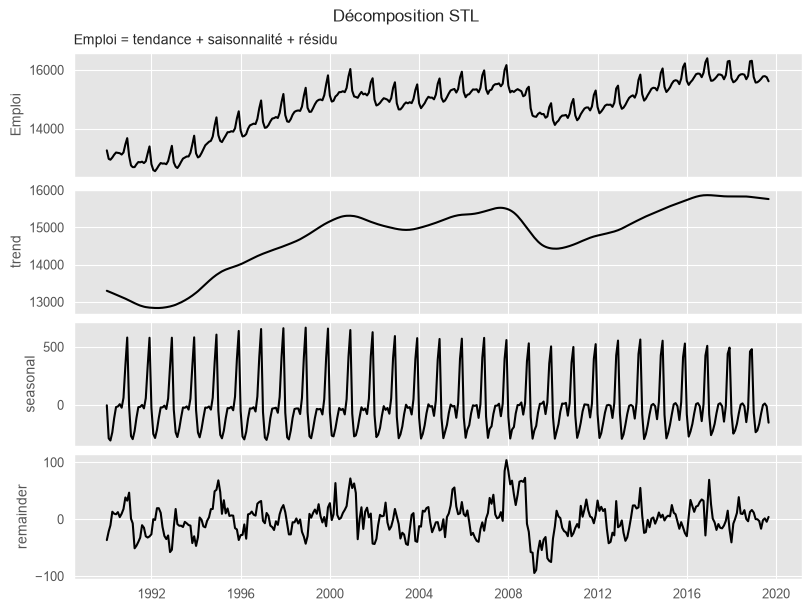

In [10]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))

sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])

axes[0].set_title(
    "Emploi = tendance + saisonnalité + résidu",
    size="medium",
    loc="left"
)

axes[0].set(ylabel="Emploi")
axes[3].set(xlabel="")

fig.suptitle("Décomposition STL")

plt.show()

Figure: Le nombre total de personnes employées dans le commerce de détail américain (en haut) et ses trois composantes additives

Les trois composants sont indiqués séparément dans les trois panneaux du bas. Ces composants peuvent être additionnés pour reconstituer les données affichées dans le panneau supérieur. Remarquez que la composante saisonnière change au fil du temps, de sorte que deux années consécutives ont des schémas similaires, mais les années éloignées peuvent avoir des schémas saisonniers différents. Le reste de la composante montrée dans le panneau inférieur correspond à ce qui reste lorsque les composantes saisonnières et du cycle de tendance ont été soustraites des données.

### Données désaisonnières

Si la composante saisonnière est retirée des données originales, les valeurs résultantes sont les données « ajustées saisonnièrement ». Pour une décomposition additive, les données désaisonnières sont données par :

$$
y_t - S_t
$$

et pour les données multiplicatives, les valeurs désaisonnières sont obtenues en utilisant :

$$
\frac{y_t}{S_t}
$$

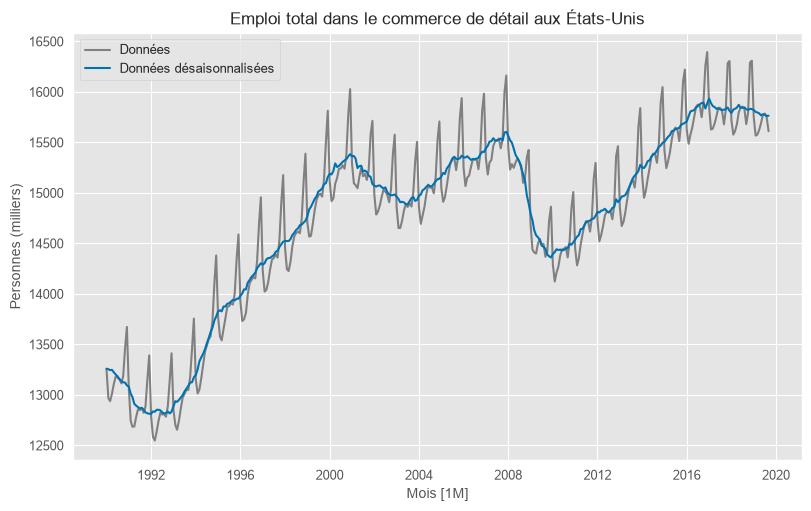

In [11]:
df = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])

fig, ax = plt.subplots()

sns.lineplot(
    data=df,
    x="ds",
    y="data",
    color="gray",
    label="Données"
)

sns.lineplot(
    data=df,
    x="ds",
    y="adj",
    color="#0072B2",
    label="Données désaisonnalisées"
)

ax.set(
    title="Emploi total dans le commerce de détail aux États-Unis",
    xlabel="Mois [1M]",
    ylabel="Personnes (milliers)",
)

plt.show()

Figure: Données d’emploi dans le commerce de détail, désaisonnées (bleu) et données originales (gris)

Si la variation due à la saisonnalité n’est pas d’intérêt principal, la série ajustée selon les variations peut être utile. Par exemple, les données mensuelles sur le chômage sont généralement désaisonnées afin de mettre en évidence la variation due à l’état sous-jacent de l’économie plutôt qu’à la variation saisonnière. Une augmentation du chômage due aux jeunes sortant d’école cherchant un emploi est une variation saisonnière, tandis qu’une augmentation du chômage due à une récession économique est non saisonnière. La plupart des analystes économiques qui étudient les données sur le chômage s’intéressent davantage à la variation non saisonnière. Par conséquent, les données sur l’emploi (et de nombreuses autres séries économiques) sont généralement ajustées selon les saisons.

Les séries désaisonnières comprennent le reste ainsi que le cycle de tendance. Par conséquent, ils ne sont pas « lisses », et les « baisses » ou « remontées » peuvent être trompeuses. Si le but est de rechercher des tournants dans une série et d’interpréter tout changement de direction, il vaut mieux utiliser la composante du cycle de tendance plutôt que les données désaisonnières.

## Moyennes mobiles

La méthode classique de décomposition par série temporelle est apparue dans les années 1920 et a été largement utilisée jusqu’aux années 1950. Elle constitue encore la base de nombreuses méthodes de décomposition en séries temporelles, il est donc important de comprendre son fonctionnement. La première étape d’une décomposition classique consiste à utiliser une méthode de moyenne mobile pour estimer le cycle de tendance, nous commençons donc par discuter des moyennes mobiles.

### Lissage de la moyenne mobile

Une moyenne mobile de l’ordre `m` peut s’écrire comme

$$
T_t = \frac{1}{m}\sum_{j=-k}^{k}y_{t+j},

$$

où `m=2k+1`. C’est-à-dire l’estimation du cycle de tendance à l’instant `t` est obtenu en moyennant les valeurs des séries temporelles dans `k` périodes de `t`. Les observations proches dans le temps sont également susceptibles d’être proches en valeur. Ainsi, la moyenne élimine une partie de l’aléa dans les données, laissant une composante de cycle de tendance fluide. Nous appelons cela un **`m`-MA**, c’est-à-dire une moyenne mobile d’ordre `m`.

Par exemple, considérons les exportations de biens et services pour l’Australie en pourcentage du PIB de 1960 à 2017. Les données sont également présentées dans le tableau ci-dessous.

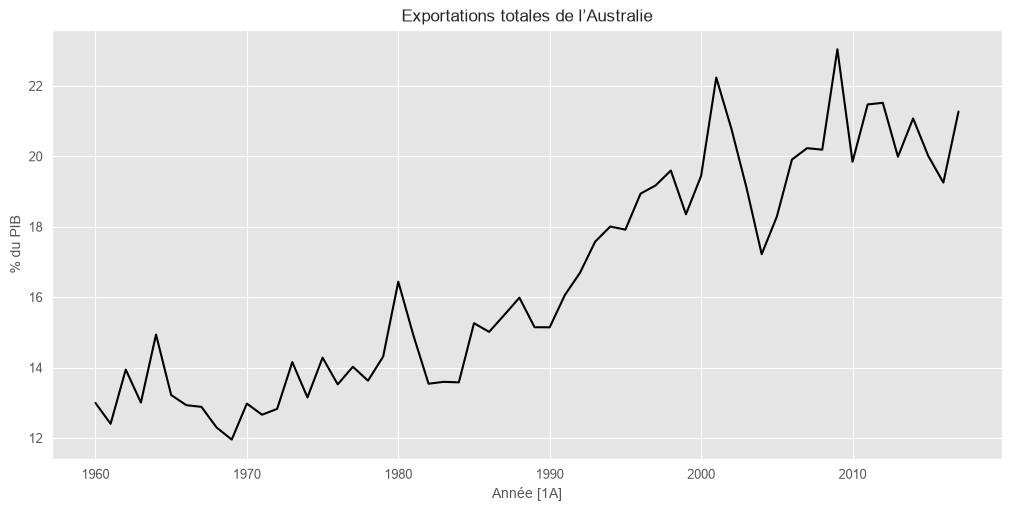

In [12]:

global_economy = pd.read_csv("data/global_economy.csv")

df = global_economy.loc[
    lambda x: x["unique_id"] == "Australia"
]

plt.figure(figsize=(10, 5))

plt.plot(
    df["ds"],
    df["Exports"]
)

plt.xlabel("Année [1A]")
plt.ylabel("% du PIB")
plt.title("Exportations totales de l’Australie")
plt.grid(True)

plt.show()



Figure: Exportations australiennes de biens et services : 1960–2017

| **Année** | **Exportations** | **5-MA** |
| --------- | ---------------- | -------- |
| 1960      | 12.99            |          |
| 1961      | 12.40            |          |
| 1962      | 13.94            | 13.46    |
| 1963      | 13.01            | 13.50    |
| 1964      | 14.94            | 13.61    |
| 1965      | 13.22            | 13.40    |
| 1966      | 12.93            | 13.25    |
| 1967      | 12.88            | 12.66    |
| …         | …                | …        |
| 2010      | 19.84            | 21.21    |
| 2011      | 21.47            | 21.17    |
| 2012      | 21.52            | 20.78    |
| 2013      | 19.99            | 20.81    |
| 2014      | 21.08            | 20.37    |
| 2015      | 20.01            | 20.32    |
| 2016      | 19.25            |          |
| 2017      | 21.27            |          |


Dans la dernière colonne de ce tableau, une **moyenne mobile d’ordre 5 (5-MA)** est montrée, fournissant une estimation du **cycle-tendance**.

La première valeur de cette colonne est la moyenne des cinq premières observations, **1960–1964** ; la deuxième valeur dans la colonne des **5-MA** est la moyenne des valeurs pour **1961–1965** ; et ainsi de suite.

Chaque valeur dans la colonne **5-MA** correspond à la moyenne des observations sur la fenêtre de cinq ans centrée sur l’année correspondante.

La colonne **5-MA** contient les valeurs de $\hat{T}_t$ avec :

$$
k = 2
$$

et

$$
m = 2k + 1 = 5
$$

Il n’y a aucune valeur pour les **deux premières années** ni pour les **deux dernières années**, car nous n’avons pas deux observations de part et d’autre de ces années.

Plus tard, nous utiliserons des méthodes plus sophistiquées d’estimation du cycle-tendance qui permettent d’obtenir des estimations proches des points de départ.

Cela se calcule facilement en utilisant la fonction `rolling()` de **pandas**. Dans ce cas, nous utilisons une fenêtre de taille `5`. Notez qu’il faut fixer `center=True` afin que la moyenne mobile soit centrée autour de chaque observation.


In [13]:
aus_exports = (
    global_economy
    .loc[lambda x: x["unique_id"] == "Australia"]
    .assign(MA_5=lambda x: x["Exports"].rolling(5, center=True).mean())
)

Pour voir à quoi ressemble l’estimation du cycle de tendance, nous la représentons avec les données originales

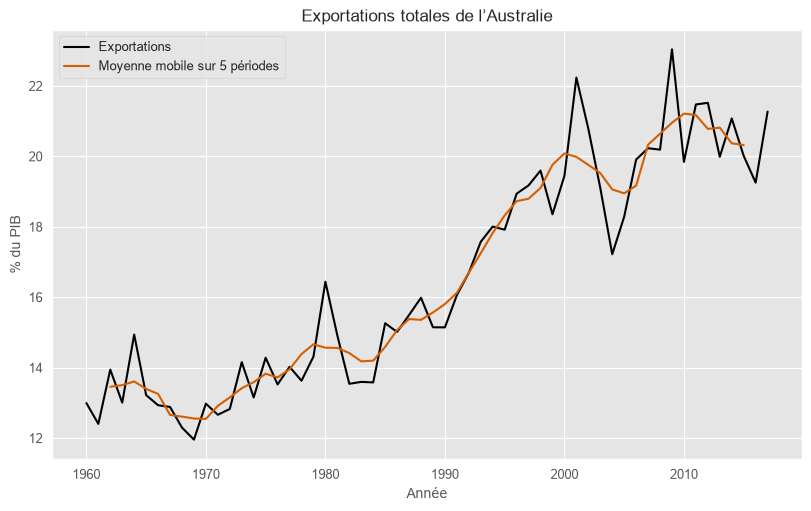

In [14]:
fig, ax = plt.subplots()

sns.lineplot(
    data=aus_exports,
    x="ds",
    y="Exports",
    color="black",
    label="Exportations"
)

sns.lineplot(
    data=aus_exports,
    x="ds",
    y="MA_5",
    color="#D55E00",
    label="Moyenne mobile sur 5 périodes"
)

ax.set(
    title="Exportations totales de l’Australie",
    xlabel="Année",
    ylabel="% du PIB",
)

plt.show()

### Moyennes mobiles des moyennes mobiles

Il est possible d’appliquer une moyenne mobile à une moyenne mobile. Une raison de cela est de rendre une moyenne mobile d’ordre pair symétrique.

Par exemple, on peut prendre une moyenne mobile d’ordre 4, puis appliquer une autre moyenne mobile d’ordre 2 aux résultats. Dans le tableau suivant, cela a été fait pour les premières années des données trimestrielles australiennes sur la production de bière.

In [15]:
aus_production = pd.read_csv("data/aus_production.csv",
    parse_dates=["ds"])
beer = (
    aus_production[["ds", "Beer"]]
    .loc[lambda x: x["ds"] >= "1992"]
    .reset_index(drop=True)
)
beer["4-MA"] = beer["Beer"].rolling(4, center=True).mean().shift(-1)
beer["2x4-MA"] = beer["4-MA"].rolling(2, center=True).mean()

**Tableau 3.1 :** Une moyenne mobile d’ordre 4 a été appliquée aux données trimestrielles sur la bière, suivie d’une moyenne mobile d’ordre 2.

| **ds**       | **Bière** | **4-MA** | **2x4-MA** |
|-------------|----------:|---------:|-----------:|
| 0           | 1992-01-01 | 443 |        |        |
| 1           | 1992-04-01 | 410 | 451.25 |        |
| 2           | 1992-07-01 | 420 | 448.75 | 450.00 |
| 3           | 1992-10-01 | 532 | 451.50 | 450.12 |
| 4           | 1993-01-01 | 433 | 449.00 | 450.25 |
| 5           | 1993-04-01 | 421 | 444.00 | 446.50 |
| ...         | ...        | ... | ...    | ...    |
| 68          | 2009-01-01 | 415 | 430.00 | 428.88 |
| 69          | 2009-04-01 | 398 | 430.00 | 430.00 |
| 70          | 2009-07-01 | 419 | 429.75 | 429.88 |
| 71          | 2009-10-01 | 488 | 423.75 | 426.75 |
| 72          | 2010-01-01 | 414 |        |        |
| 73          | 2010-04-01 | 374 |        |        |


La notation **`2×4`-MA** dans la dernière colonne signifie une **4-MA suivie d’une 2-MA**. Les valeurs de la dernière colonne sont obtenues en prenant une moyenne mobile d’ordre 2 des valeurs de la colonne précédente.

Par exemple, les deux premières valeurs de la colonne **4-MA** sont :

$$
451.25 = \frac{443+410+420+532}{4}
$$

et

$$
448.75 = \frac{410+420+532+433}{4}
$$

La première valeur dans la colonne **2×4-MA** est la moyenne de ces deux valeurs :

$$
450 = \frac{451.25+448.75}{2}
$$

Lorsqu’une **2-MA** suit une moyenne mobile d’ordre pair (comme 4), on parle de **moyenne mobile centrée d’ordre 4**. Cela s’explique par le fait que les résultats sont désormais symétriques.

Pour voir que c’est le cas, on peut écrire la **2×4-MA** comme suit :

$$
\hat{T}_t =
\frac{1}{2}
\left[
\frac{1}{4}
(y_{t-2}+y_{t-1}+y_t+y_{t+1})
+
\frac{1}{4}
(y_{t-1}+y_t+y_{t+1}+y_{t+2})
\right]
$$

ce qui donne :

$$
\hat{T}_t =
\frac{1}{8}y_{t-2}
+
\frac{1}{4}y_{t-1}
+
\frac{1}{4}y_t
+
\frac{1}{4}y_{t+1}
+
\frac{1}{8}y_{t+2}.
$$

Il s’agit désormais d’une **moyenne pondérée des observations qui est symétrique**.

D’autres combinaisons de moyennes mobiles sont également possibles. Par exemple, une **`3×3`-MA** est souvent utilisée et consiste en une moyenne mobile d’ordre 3 suivie d’une autre moyenne mobile d’ordre 3.

En général, une **MA d’ordre pair** doit être suivie d’une autre **MA d’ordre pair** pour la rendre symétrique. De même, une **MA d’ordre impair** doit être suivie d’une autre **MA d’ordre impair**.

### Estimation du cycle-tendance à partir de données saisonnières

L’utilisation la plus courante des moyennes mobiles centrées est d’estimer le **cycle-tendance à partir de données saisonnières**.

Considérons la **`2×4`-MA** :

$$
\hat{T}_t =
\frac{1}{8}y_{t-2}
+
\frac{1}{4}y_{t-1}
+
\frac{1}{4}y_t
+
\frac{1}{4}y_{t+1}
+
\frac{1}{8}y_{t+2}.
$$

Appliqué aux données trimestrielles, chaque trimestre de l’année reçoit un poids égal puisque le premier et le dernier terme s’appliquent au même trimestre des années consécutives.

Par conséquent, la variation saisonnière sera moyennée et les valeurs résultantes de $\hat{T}_t$ ne contiendront que peu ou pas de variation saisonnière.

Un effet similaire serait obtenu en utilisant une **`2×8`-MA** ou une **`2×12`-MA** sur des données trimestrielles.

En général, une **`2×m`-MA** est équivalente à une moyenne mobile pondérée d’ordre $m+1$, où toutes les observations prennent le poids $\frac{1}{m}$, sauf pour le premier et le dernier terme qui prennent des poids $\frac{1}{2m}$.

Ainsi, si la période saisonnière est régulière et d’ordre $m$, nous utilisons une **`2×m`-MA** pour estimer le cycle-tendance.

Si la période saisonnière est impaire et d’ordre $m$, nous utilisons un **`m`-MA** pour estimer le cycle-tendance.

Par exemple :

- une **`2×12`-MA** peut être utilisée pour estimer le cycle-tendance des données mensuelles avec une saisonnalité annuelle ;
- une **7-MA** peut être utilisée pour estimer le cycle-tendance des données quotidiennes avec une saisonnalité hebdomadaire.

D’autres choix pour l’ordre de la MA entraînent généralement des estimations du cycle-tendance contaminées par la saisonnalité des données.



Exemple : Emploi dans le secteur de la vente au détail américaine

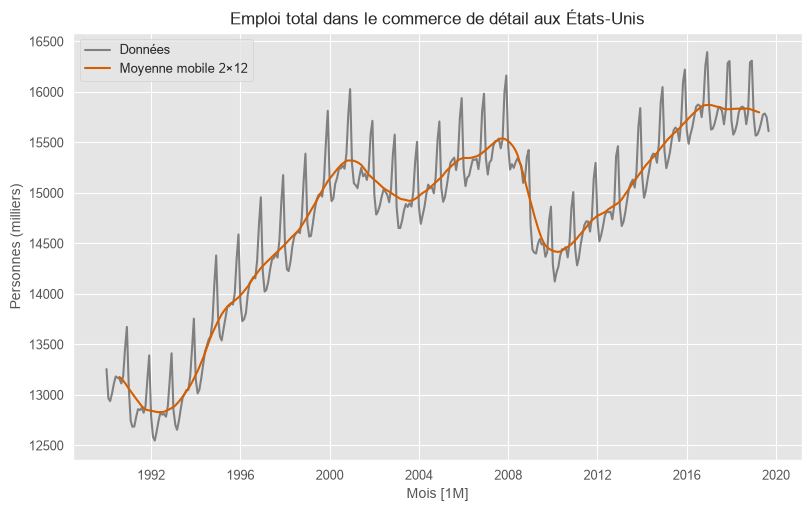

In [16]:
df = us_retail_employment.copy()

df["12-MA"] = df["y"].rolling(window=12, center=True).mean()
df["2x12-MA"] = df["12-MA"].rolling(window=2, center=True).mean()

fig, ax = plt.subplots()

sns.lineplot(
    data=df,
    x="ds",
    y="y",
    color="grey",
    label="Données"
)

sns.lineplot(
    data=df,
    x="ds",
    y="2x12-MA",
    color="#D55E00",
    label="Moyenne mobile 2×12"
)

ax.set(
    title="Emploi total dans le commerce de détail aux États-Unis",
    xlabel="Mois [1M]",
    ylabel="Personnes (milliers)",
)

plt.show()

Figure : Un 2x12-MA appliqué à la série d’emploi dans le commerce de détail aux États-Unis.

Une **`2×12`-MA** est appliquée au nombre total de personnes employées dans le secteur de la distribution américaine.

Remarquez que la ligne lissée ne montre aucune saisonnalité ; elle est presque identique au cycle-tendance présenté à [la Figure 3.6](https://otexts.com/fpppy/03-decomposition.html#fig-empltrend), estimé à l’aide d’une méthode bien plus sophistiquée qu’une moyenne mobile.

Tout autre choix pour l’ordre de la moyenne mobile, à l’exception de **24, 36, etc.**, aurait produit une ligne lissée présentant certaines fluctuations saisonnières.

### Moyennes mobiles pondérées

Les combinaisons de moyennes mobiles donnent lieu à des **moyennes mobiles pondérées**.

Par exemple, la **`2×4`-MA** discutée précédemment est équivalente à une **5-MA pondérée** avec des poids donnés par :

$$
\left[\frac{1}{8},\frac{1}{4},\frac{1}{4},\frac{1}{4},\frac{1}{8}\right]
$$

En général, une **moyenne mobile pondérée d’ordre $m$** peut s’écrire comme :

$$
\hat{T}_t = \sum_{j=-k}^{k} a_j y_{t+j},
$$

où :

$$
k = \frac{m-1}{2}
$$

et les poids sont donnés par :

$$
[a_{-k},\ldots,a_k].
$$

Il est important que tous les poids soient **sommés à 1** et qu’ils soient **symétriques**, de sorte que :

$$
a_j = a_{-j}.
$$

La simple **m-MA** est un cas particulier dans lequel tous les poids sont égaux à :

$$
\frac{1}{m}.
$$

Un avantage majeur des **moyennes mobiles pondérées** est qu’elles permettent une estimation plus fluide du cycle-tendance.

Au lieu que les observations entrent et sortent du calcul avec un poids constant, leur poids **augmente progressivement puis diminue progressivement**, ce qui produit une courbe plus douce.

## Méthodes utilisées par les agences officielles de statistiques

Les agences officielles de statistiques, telles que le **Bureau du recensement des États-Unis** et le **Bureau australien des statistiques**, sont responsables de nombreuses séries temporelles économiques et sociales officielles.

Ces agences ont développé leurs propres procédures de décomposition, principalement utilisées pour **l’ajustement saisonnier**. La plupart utilisent des variantes de la méthode **X-11**, de la méthode **SEATS**, ou une combinaison des deux.

Ces méthodes sont spécifiquement conçues pour traiter les données **trimestrielles et mensuelles**, qui constituent les séries les plus couramment utilisées par les agences officielles de statistiques. Elles ne sont généralement pas conçues pour traiter d’autres types de saisonnalité, comme les données **quotidiennes, horaires ou hebdomadaires**.

### Méthode X-11

La méthode **X-11** a été développée à l’origine par le **Bureau du recensement des États-Unis**, puis perfectionnée par **Statistique Canada**.

Elle est basée sur la **décomposition classique**, mais comprend de nombreuses étapes et fonctionnalités supplémentaires permettant de surmonter les principales limites de cette dernière.

En particulier, des estimations du **cycle-tendance** sont disponibles pour toutes les observations, y compris les points finaux, et la composante saisonnière peut évoluer progressivement au fil du temps.

La méthode X-11 prend également en compte :

- les variations liées aux **jours ouvrables** ;
- les **effets des jours fériés** ;
- les effets de certains **prédicteurs connus** ;
- les **valeurs aberrantes** ;
- les changements de niveau dans la série temporelle.

Elle peut être utilisée pour les décompositions **additives** et **multiplicatives**.

Le processus est entièrement automatisé et tend à être particulièrement robuste face aux valeurs aberrantes et aux changements de niveau dans les séries temporelles.

Les détails de la méthode X-11 sont décrits dans Dagum & Bianconcini (2016).

### Méthode SEATS

**SEATS** signifie **« Seasonal Extraction in ARIMA Time Series »**, c’est-à-dire **« extraction saisonnière dans les séries temporelles ARIMA »**.

Cette procédure a été développée à la **Banque d’Espagne** et est aujourd’hui largement utilisée par les agences gouvernementales du monde entier.

La méthode SEATS repose sur des modèles **ARIMA** pour décomposer une série temporelle en différentes composantes, notamment la tendance, la saisonnalité et la composante irrégulière.

Les détails techniques de cette méthode dépassent le cadre de cette section. Une présentation complète est disponible dans Dagum & Bianconcini (2016).

## Décomposition STL

STL est une méthode polyvalente et robuste pour décomposer les séries temporelles. STL est l’acronyme de **« Seasonal and Trend Decomposition using Loess »**, tandis que **Loess** est une méthode d’estimation des relations non linéaires.

La méthode STL a été développée par Cleveland et al. (1990), puis étendue pour traiter plusieurs schémas saisonniers par Bandara et al. (2025).

STL présente plusieurs avantages par rapport à la décomposition classique ainsi qu’aux méthodes SEATS et X-11 :

- Contrairement à SEATS et X-11, STL gère **tout type de saisonnalité**, et pas uniquement les données mensuelles et trimestrielles.
- La **composante saisonnière** peut évoluer dans le temps, et le taux de variation peut être contrôlé par l’utilisateur.
- La **fluidité du cycle-tendance** peut également être contrôlée par l’utilisateur.
- STL peut être **robuste aux valeurs aberrantes**. L’utilisateur peut spécifier une décomposition robuste afin que des observations inhabituelles n’affectent pas les estimations du cycle-tendance et de la composante saisonnière. Elles affecteront cependant la composante résiduelle.

D’un autre côté, STL présente certains inconvénients. En particulier, elle ne gère pas automatiquement les variations liées aux **jours ouvrables** ou au **calendrier**, et elle fournit principalement des fonctionnalités pour les décompositions additives.

Une décomposition multiplicative peut être obtenue en prenant d’abord le **logarithme des données**, puis en rétro-transformant les composantes.

Les décompositions intermédiaires entre les formes additive et multiplicative peuvent être obtenues en utilisant une **transformation de Box-Cox** avec :

$$
0 < \lambda < 1
$$

Une valeur de :

$$
\lambda = 0
$$

donne une décomposition multiplicative, tandis que :

$$
\lambda = 1
$$

donne une décomposition additive.

La meilleure façon de commencer à apprendre à utiliser STL est d’observer quelques exemples et d’expérimenter avec les différents réglages.

Un premier exemple montre une décomposition STL appliquée à la série du **nombre total de personnes employées dans le commerce de détail aux États-Unis**.

Une autre décomposition STL utilise un **cycle-tendance plus flexible**, une **composante saisonnière fixe** et l’option **robuste**.

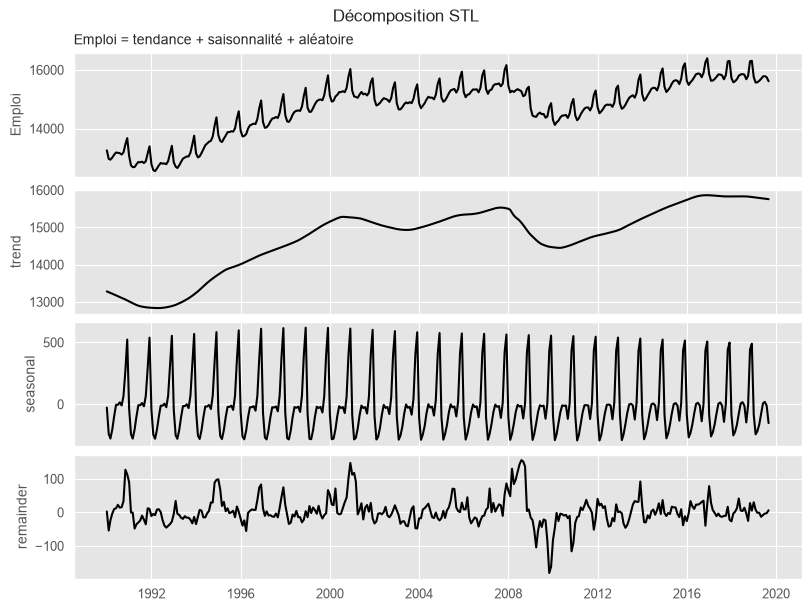

In [17]:
stl = STL(
    us_retail_employment["y"],
    period=12,
    seasonal=13,
    trend=21,
    robust=True
)

res_stl = stl.fit()

dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res_stl.trend,
    "seasonal": res_stl.seasonal,
    "remainder": res_stl.resid,
}).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))

sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])

axes[0].set_title(
    "Emploi = tendance + saisonnalité + aléatoire",
    size="medium",
    loc="left"
)

axes[0].set(ylabel="Emploi")
axes[3].set(xlabel="")

fig.suptitle("Décomposition STL")

plt.show()

Figure : Emploi total dans le commerce de détail aux États-Unis (haut) et ses trois composantes additives obtenues d’une décomposition robuste des STL avec un cycle de tendance flexible et une saisonnalité fixe



Les deux principaux paramètres à choisir lors de l’utilisation de **STL** sont `seasonal` et `trend`.

Le paramètre `seasonal` correspond à la **durée du lisseur saisonnier**, tandis que `trend` correspond à la **durée du lisseur de tendance**.

Ces paramètres contrôlent la rapidité avec laquelle les composantes **saisonnière** et **cycle-tendance** peuvent évoluer. Des valeurs plus petites permettent aux composantes de changer plus rapidement.

Les fenêtres `seasonal` et `trend` doivent être des **nombres impairs**.

Par défaut, la fonction `STL()` de `statsmodels` fournit une décomposition STL automatisée et pratique. Elle offre généralement un bon équilibre entre un **surajustement de la saisonnalité** et une évolution trop lente de celle-ci au cours du temps.

Cependant, comme pour toute procédure automatisée, les paramètres par défaut peuvent nécessiter des ajustements pour certaines séries temporelles.

Dans ce cas, le réglage par défaut de la fenêtre de tendance produit une composante **cycle-tendance trop rigide**. En conséquence, le signal associé à la **crise financière mondiale de 2008** s’est retrouvé en partie dans la composante résiduelle.

La sélection d’une **fenêtre de tendance plus courte** permet d’obtenir une composante cycle-tendance plus flexible et améliore ainsi la décomposition.